# Evaluation

In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "/kaggle/input/models/khoirotunhisan/skripsi-v2/tfjs/default/1/indobert_absa_final"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [2]:
ASPEK_KEYWORDS = {
    "rasa": [
        "rasa", "enak", "lezat", "manis", "pahit", "nagih", "coklat",
        "flavor", "taste", "ga eneg", "tidak eneg", "lumer"
    ],
    "kemasan": [
        "kemasan", "bungkus", "packaging", "box", "kotak",
        "paper bag", "plastik", "desain", "tampilan", "wrap"
    ],
    "kualitas": [
        "kualitas", "mutu", "original", "ori", "rusak", "retak",
        "meleleh", "leleh", "hancur", "cacat", "kadaluarsa",
        "expired", "exp", "tanggal"
    ],
    "pelayanan": [
        "pelayanan", "seller", "penjual", "admin", "respon",
        "responsif", "ramah", "cepat", "pengiriman", "kirim",
        "packing", "dibalas", "cs"
    ],
    "harga": [
        "harga", "murah", "mahal", "terjangkau", "worth it",
        "sesuai harga", "promo", "diskon", "ongkir"
    ]
}

In [3]:
def detect_aspects(text):
    text = text.lower()
    aspek = []

    for a, kws in ASPEK_KEYWORDS.items():
        if any(k in text for k in kws):
            aspek.append(a)

    return aspek

In [4]:
id2label = {0: "negatif", 1: "netral", 2: "positif"}

def predict_sentiment(text, aspek):
    input_text = text + " [ASPEK] " + aspek

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits, dim=1).item()

    return id2label[pred_id]

In [5]:
def predict_absa(text):
    aspek_list = detect_aspects(text)

    hasil = []

    for a in aspek_list:
        sent = predict_sentiment(text, a)

        hasil.append({
            "aspek": a,
            "sentiment": sent
        })

    return hasil

In [6]:
import pandas as pd

df = pd.read_excel("/kaggle/input/datasets/khoirotunhisan/unlabeled/train_unlabeled.xlsx")
df = df.dropna(subset=["ulasan_clean"])

rows = []

for ulasan in df["ulasan_clean"]:
    hasil = predict_absa(ulasan)

    for h in hasil:
        rows.append({
            "ulasan_clean": ulasan,
            "aspek": h["aspek"],
            "sentiment": h["sentiment"]
        })

hasil_df = pd.DataFrame(rows)

In [7]:
hasil_df.to_excel("hasil_absa-v2.xlsx", index=False)

# Deployment  

## 1. Load Model

In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "/kaggle/input/models/khoirotunhisan/skripsi-v2/tfjs/default/1/indobert_absa_final"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## 2. Aspect Detection

In [17]:
ASPEK_KEYWORDS = {
    "rasa": [
        "rasa", "enak", "lezat", "manis", "pahit", "nagih", "coklat",
        "flavor", "taste", "ga eneg", "tidak eneg", "lumer"
    ],
    "kemasan": [
        "kemasan", "bungkus", "packaging", "box", "kotak",
        "paper bag", "plastik", "desain", "tampilan", "wrap"
    ],
    "kualitas": [
        "kualitas", "mutu", "original", "ori", "rusak", "retak",
        "meleleh", "leleh", "hancur", "cacat", "kadaluarsa",
        "expired", "exp", "tanggal"
    ],
    "pelayanan": [
        "pelayanan", "seller", "penjual", "admin", "respon",
        "responsif", "ramah", "cepat", "pengiriman", "kirim",
        "packing", "dibalas", "cs"
    ],
    "harga": [
        "harga", "murah", "mahal", "terjangkau", "worth it",
        "sesuai harga", "promo", "diskon", "ongkir"
    ]
}

def detect_aspects(text):
    text = text.lower()
    return [a for a, kws in ASPEK_KEYWORDS.items() if any(k in text for k in kws)]

## 3. Sentiment Prediction

In [26]:
id2label = model.config.id2label

def predict_sentiment(text, aspek):
    input_text = text + " [ASPEK] " + aspek

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits, dim=1).item()
    return id2label[pred_id]

## 4. ABSA Function

In [49]:
def predict_absa(text):
    aspek_list = detect_aspects(text)

    hasil = []
    for a in aspek_list:
        sent = predict_sentiment(text, a)
        hasil.append({"aspek": a, "sentiment": sent})

    return hasil

## 5. Apply ke Data Unlabeled

In [50]:
import pandas as pd

df = pd.read_excel("/kaggle/input/datasets/khoirotunhisan/unlabeled-2/unlabeled.xlsx")
df = df.dropna(subset=["ulasan_clean"])

rows = []

for ulasan in df["ulasan_clean"]:
    hasil = predict_absa(ulasan)

    for h in hasil:
        rows.append({
            "ulasan_clean": ulasan,
            "aspek": h["aspek"],
            "sentiment": h["sentiment"]
        })

hasil_df = pd.DataFrame(rows)

## 6. Save Hasil

In [63]:
hasil_df.to_excel("hasil_deployment_absa.xlsx", index=False)

# Analisis

### 1. Distribusi Sentimen

In [75]:
hasil_df["sentiment"].value_counts()

sentiment
positif    679
netral      11
negatif      8
Name: count, dtype: int64

### 2. Sentimen per Aspek

In [9]:
hasil_df.groupby("aspek")["sentiment"].value_counts()

aspek      sentiment
harga      positif       80
           negatif        2
           netral         2
kemasan    positif       71
kualitas   positif      171
           netral         3
           negatif        1
pelayanan  positif      129
           negatif        3
rasa       positif      228
           netral         6
           negatif        2
Name: count, dtype: int64

### 3. Persentase per Aspek

In [11]:
aspek_summary = hasil_df.groupby(["aspek","sentiment"]).size().unstack(fill_value=0)

aspek_summary_pct = aspek_summary.div(aspek_summary.sum(axis=1), axis=0) * 100

aspek_summary_pct

sentiment,negatif,netral,positif
aspek,,,
harga,2.380952,2.380952,95.238095
kemasan,0.000000,0.000000,100.000000
kualitas,0.571429,1.714286,97.714286
pelayanan,2.272727,0.000000,97.727273
rasa,0.847458,2.542373,96.610169


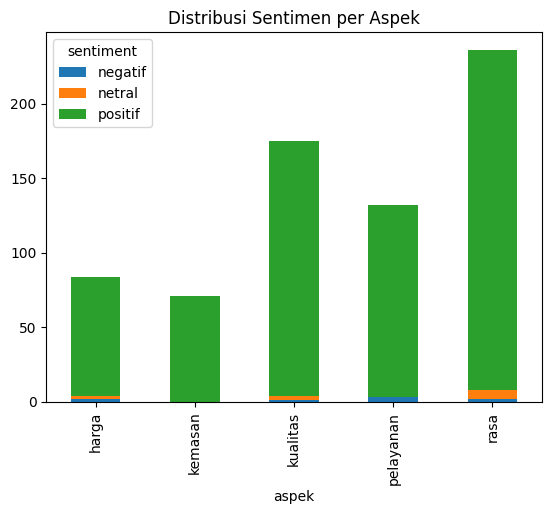

In [12]:
import matplotlib.pyplot as plt

aspek_summary.plot(kind="bar", stacked=True)
plt.title("Distribusi Sentimen per Aspek")
plt.show()

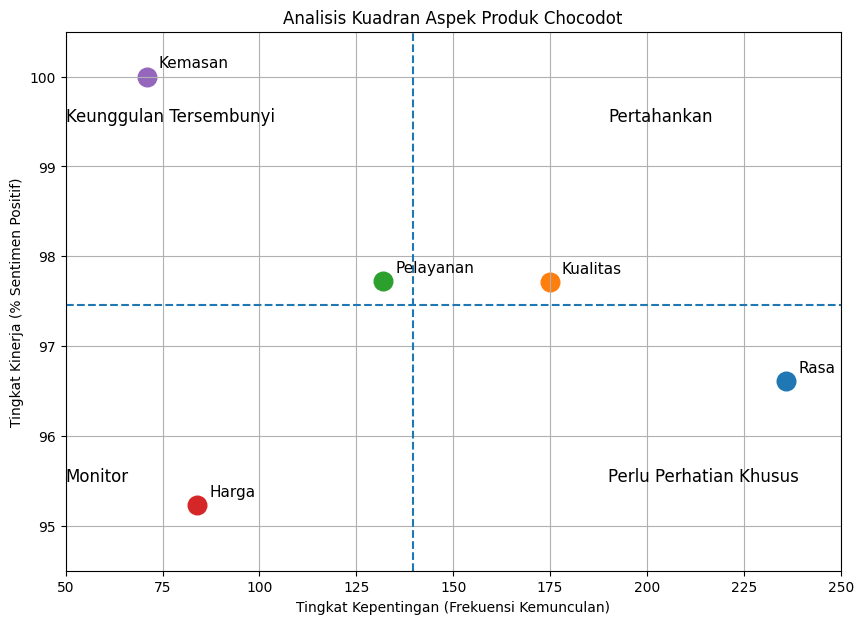

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data aspek
aspects = ['Rasa', 'Kualitas', 'Pelayanan', 'Harga', 'Kemasan']
frequency = [236, 175, 132, 84, 71]
positive_sentiment = [96.61, 97.71, 97.72, 95.23, 100.00]

# Hitung rata-rata untuk garis kuadran
mean_freq = np.mean(frequency)
mean_sentiment = np.mean(positive_sentiment)

# Plot
plt.figure(figsize=(10, 7))

for i, aspect in enumerate(aspects):
    plt.scatter(frequency[i], positive_sentiment[i], s=180)
    plt.text(frequency[i]+3, positive_sentiment[i]+0.1, aspect, fontsize=11)

# Garis pembagi kuadran
plt.axvline(mean_freq, linestyle='--')
plt.axhline(mean_sentiment, linestyle='--')

# Label kuadran
plt.text(190, 99.5, 'Pertahankan', fontsize=12)
plt.text(50, 99.5, 'Keunggulan Tersembunyi', fontsize=12)
plt.text(190, 95.5, 'Perlu Perhatian Khusus', fontsize=12)
plt.text(50, 95.5, 'Monitor', fontsize=12)

# Judul dan label
plt.title('Analisis Kuadran Aspek Produk Chocodot')
plt.xlabel('Tingkat Kepentingan (Frekuensi Kemunculan)')
plt.ylabel('Tingkat Kinerja (% Sentimen Positif)')

plt.xlim(50, 250)
plt.ylim(94.5, 100.5)

plt.grid(True)
plt.show()